# 数据集加载及预处理

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
from sklearn.datasets import fetch_california_housing
from sklearn.preprocessing import StandardScaler
import numpy as np

# 加载加利福尼亚房价数据集
california_housing = fetch_california_housing(data_home='./data')
X, y = california_housing.data, california_housing.target

# 先划分数据集，然后在训练集上fit标准化器
from sklearn.model_selection import train_test_split

# 首先划分训练集和临时集（验证集+测试集）
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# 再将临时集划分为验证集和测试集
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42
)

# 数据标准化（只对特征进行标准化，标签不进行标准化）
# 在训练集上fit_transform，验证集和测试集只进行transform
scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_val_scaled = scaler_X.transform(X_val)
X_test_scaled = scaler_X.transform(X_test)

# 自定义Dataset类
class CaliforniaHousingDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.FloatTensor(X)
        self.y = torch.FloatTensor(y)
    
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx].unsqueeze(0)

# 创建数据集
train_dataset = CaliforniaHousingDataset(X_train_scaled, y_train)
val_dataset = CaliforniaHousingDataset(X_val_scaled, y_val)
test_dataset = CaliforniaHousingDataset(X_test_scaled, y_test)

# 创建DataLoader
batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"数据集大小: 总计 {len(X)}")
print(f"训练集: {len(train_dataset)} 样本")
print(f"验证集: {len(val_dataset)} 样本")
print(f"测试集: {len(test_dataset)} 样本")
print(f"特征维度: {X.shape[1]}")


数据集大小: 总计 20640
训练集: 14448 样本
验证集: 3096 样本
测试集: 3096 样本
特征维度: 8


In [2]:
for x,y in train_loader:
    print(x.shape)
    print(y.shape)
    break

torch.Size([64, 8])
torch.Size([64, 1])


In [3]:


# 演示批量情况
print(f"\n批量情况演示:")
y_batch = torch.tensor([1.2, 2.3, 3.4])  # 3个样本的标签
print(f"批量标签原始形状: {y_batch.shape}")
y_batch_unsqueezed = y_batch.unsqueeze(1)  # 在第1维增加维度
print(f"批量标签unsqueeze(1)后形状: {y_batch_unsqueezed.shape}")
print(f"批量标签内容:\n{y_batch_unsqueezed}")



批量情况演示:
批量标签原始形状: torch.Size([3])
批量标签unsqueeze(1)后形状: torch.Size([3, 1])
批量标签内容:
tensor([[1.2000],
        [2.3000],
        [3.4000]])


# 搭建模型

In [ ]:
import torch
import torch.nn as nn
import math

class CustomizedLinear(nn.Module):
    """
    这是一个自定义的线性层，实现方式类似于PyTorch中自带的nn.Linear，但我们手动实现了参数的初始化和前向传播。
    """
    def __init__(self, in_features, out_features, bias=True):
        """
        初始化方法

        参数说明：
        - in_features: 输入特征的数量（例如，如果输入向量是10维，这里就填10）
        - out_features: 输出特征的数量（例如，如果希望输出5维，这里就填5）
        - bias: 是否包含偏置项（默认为True）

        主要步骤：
        1. 保存输入和输出维度
        2. 创建权重参数weight（通常shape是[输出特征数, 输入特征数]，不过这里和nn.Linear不同，使用的是[in_features, out_features]）
        3. 如果需要偏置，则创建偏置参数bias（shape是[输出特征数]）
        4. 调用reset_parameters初始化参数
        """
        super().__init__()
        self.in_features = in_features
        self.out_features = out_features

        # 创建权重参数。注意shape为(in_features, out_features)，这与nn.Linear的(out_features, in_features)不同
        # 权重是需要模型学习的参数。nn.Parameter会把其加入到模型参数列表中，参与优化
        self.weight = nn.Parameter(torch.empty(in_features, out_features))
        if bias:
            # 创建偏置参数，同样需要学习
            self.bias = nn.Parameter(torch.empty(out_features))
        else:
            # 如果不使用偏置，需要向模块注册一个名为“bias”的None参数
            self.register_parameter('bias', None)
        
        # 初始化权重和偏置
        self.reset_parameters()

    def reset_parameters(self):
        """
        参数初始化方法

        权重weight按照Kaiming均匀分布初始化（适合ReLU类激活函数的线性层，有助于缓解梯度消失/爆炸问题）
        偏置bias按均匀分布初始化，范围依据输入特征数量自动设置
        """
        # 使用Kaiming均匀初始化weight
        nn.init.kaiming_uniform_(self.weight, a=math.sqrt(5))
        if self.bias is not None:
            # 计算输入通道数，用于决定偏置初始化的边界范围
            fan_in = self.in_features
            bound = 1 / math.sqrt(fan_in) if fan_in > 0 else 0
            nn.init.uniform_(self.bias, -bound, bound)

    def forward(self, input):
        """
        前向传播方法

        - input: shape为(batch, in_features)
        - 返回: shape为(batch, out_features)

        实现逻辑：
        1. 用矩阵乘法torch.mm计算输入和权重的乘积：input @ weight
           注意这里权重shape为(in_features, out_features)，因此input (batch, in_features) @ weight (in_features, out_features) 得到(batch, out_features)
        2. 将偏置bias加到每一行（样本）上
        """
        return torch.mm(input, self.weight) + self.bias


In [5]:
# 定义回归模型，使用自定义的CustomizedLinear层
class HousePriceModel(nn.Module):
    def __init__(self, input_size, hidden_size=30, output_size=1):
        super(HousePriceModel, self).__init__()
        self.fc1 = CustomizedLinear(input_size, hidden_size)
        self.fc2 = CustomizedLinear(hidden_size, output_size)
        self.relu = nn.ReLU()
    
    def forward(self, x):
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        return x

# 创建模型实例
input_size = X.shape[1]  # 特征维度
model = HousePriceModel(input_size=input_size, hidden_size=30, output_size=1)

print(f"模型结构:")
print(model)
print(f"\n模型参数数量: {sum(p.numel() for p in model.parameters())}")


模型结构:
HousePriceModel(
  (fc1): CustomizedLinear()
  (fc2): CustomizedLinear()
  (relu): ReLU()
)

模型参数数量: 301


In [6]:
# 导入训练模块
from wangdao_train import Trainer, EarlyStopping, ModelCheckpoint


# 设置设备
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"使用设备: {device}")

# 初始化损失函数和优化器
criterion = nn.MSELoss()  # 均方误差损失函数，适用于回归任务
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# 初始化早停对象
early_stopping = EarlyStopping(
    patience=10,      # 容忍10个评估周期没有改善
    min_delta=0.001,  # 最小改善阈值
    mode='min'        # 监控val_loss，越小越好
)

# 初始化模型保存对象
model_checkpoint = ModelCheckpoint(
    filepath='./checkpoints/regression_model_epoch_{epoch}.ckpt',
    monitor='val_loss',
    save_best_only=True,
    mode='min',
    min_delta=0.001
)

# 创建训练器
trainer = Trainer(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    device=device,
    eval_step=50,  # 每50个batch评估一次
    early_stopping=early_stopping,
    model_checkpoint=model_checkpoint
)

# 开始训练
print("开始训练...")
trainer.train_regression(num_epochs=100)


使用设备: cpu
开始训练...
[Step 50] Val Loss: 1.6759
[Step 100] Val Loss: 0.8448
[Step 150] Val Loss: 0.6810
[Step 200] Val Loss: 0.6351
Epoch [1/100]  Train Loss: 1.3131
[Step 250] Val Loss: 0.5968
[Step 300] Val Loss: 0.5696
[Step 350] Val Loss: 0.5449
[Step 400] Val Loss: 0.5258
[Step 450] Val Loss: 0.5091
Epoch [2/100]  Train Loss: 0.5334
[Step 500] Val Loss: 0.4975
[Step 550] Val Loss: 0.4891
[Step 600] Val Loss: 0.4769
[Step 650] Val Loss: 0.4741
Epoch [3/100]  Train Loss: 0.4688
[Step 700] Val Loss: 0.4650
[Step 750] Val Loss: 0.4691
[Step 800] Val Loss: 0.4531
[Step 850] Val Loss: 0.4502
[Step 900] Val Loss: 0.4444
Epoch [4/100]  Train Loss: 0.4391
[Step 950] Val Loss: 0.4400
[Step 1000] Val Loss: 0.4375
[Step 1050] Val Loss: 0.4352
[Step 1100] Val Loss: 0.4299
Epoch [5/100]  Train Loss: 0.4188
[Step 1150] Val Loss: 0.4261
[Step 1200] Val Loss: 0.4260
[Step 1250] Val Loss: 0.4313
[Step 1300] Val Loss: 0.4231
[Step 1350] Val Loss: 0.4175
Epoch [6/100]  Train Loss: 0.4034
[Step 1400] Val

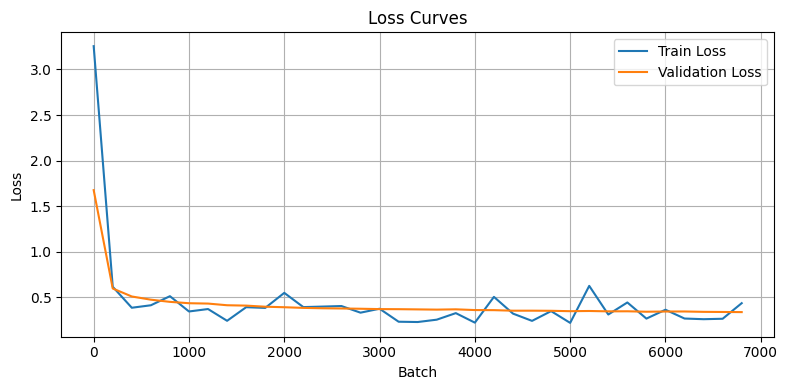

In [7]:
trainer.plot_curves(200)